In [15]:
import os
from typing import TypedDict,Annotated
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langgraph.graph.state import StateGraph,START,END
from dotenv import load_dotenv
load_dotenv()



True

In [16]:
class Parentstate(TypedDict):
    question: str
    answer_eng: str
    answer_hin:str

In [17]:
parent_llm=ChatGroq(model="openai/gpt-oss-120b",temperature=0.7,api_key=os.getenv("GROQ_API_KEY"))
subgraph_llm=ChatGroq(model="openai/gpt-oss-120b",temperature=0.7,api_key=os.getenv("GROQ_API_KEY"))

In [18]:
def translate_to_hindi(state:Parentstate):
    prompt=f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
      
    translate_text=subgraph_llm.invoke(prompt).content

    return{"answer_hin": translate_text}

      
   

In [19]:
subgraph_builder=StateGraph(Parentstate)

subgraph_builder.add_node('translate_text',translate_to_hindi)

subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text',END)
subgraph=subgraph_builder.compile()

In [20]:
def generate_answer(state:Parentstate):
    prompt=f"""You are a helpful assistant. Answer the question in English.

Question: {state["question"]}
""".strip()

    answer = parent_llm.invoke(prompt).content
    return {"answer_eng": answer}

In [ ]:
parent_builder=StateGraph(Parentstate)
parent_builder.add_node('generate_answer',generate_answer)
parent_builder.add_node('translate_subgraph',subgraph)#adding the subgraph as a node in the parent graph
parent_builder.add_edge(START,'generate_answer')

parent_builder.add_edge('generate_answer','translate_subgraph')
parent_builder.add_edge('translate_subgraph',END)
parent_graph=parent_builder.compile()



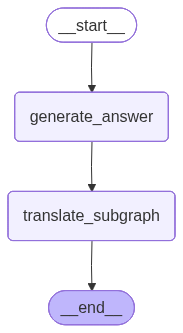

In [22]:
parent_graph

In [23]:
result=parent_graph.invoke({"question": "what is langgraph?"})

In [24]:
result

{'question': 'what is langgraph?',
 'answer_eng': '**LangGraph** is an open‑source Python library (maintained by the LangChain team) that makes it easy to build **graph‑structured, multi‑step workflows** powered by large language models (LLMs).  \n\n---\n\n## Core Idea\n\n- **Graphs, not linear chains** – While LangChain’s original “Chain” abstraction models a straight‑line sequence of LLM calls, many real‑world applications need branching, loops, conditional routing, parallel execution, or the ability to revisit previous steps. LangGraph represents a workflow as a **directed graph** where each node is a piece of logic (often an LLM call, a tool, a function, or any Python code) and edges dictate how the execution moves from one node to the next based on the current **state**.\n\n- **State‑driven execution** – The graph operates on a mutable `state` dictionary that is passed from node to node. Each node can read, modify, or add to the state, and the next edge is chosen by evaluating con